In [20]:
# Import required libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns if needed
pd.set_option('display.max_columns', None)

# Make plots look cleaner
plt.style.use('ggplot')

In [21]:

# ============================================================
# Load Clean Dataset
# ============================================================
from pathlib import Path
import pandas as pd
DOWNLOADS_DIR = Path.home() / "Downloads"
prices = pd.read_csv(
     DOWNLOADS_DIR / "stock_prices.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

benchmark = pd.read_csv(
     DOWNLOADS_DIR / "nifty50.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

In [22]:
prices.index

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-07', '2019-01-08', '2019-01-09', '2019-01-10',
               '2019-01-11', '2019-01-14',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=1730, freq=None)

In [23]:
prices.head()

,HDFC Bank,Infosys,Reliance,HUL
Date,,,,
2019-01-01,496.185822,541.725769,496.196381,1591.314453
2019-01-02,491.658508,544.984070,489.733917,1576.736206
2019-01-03,487.800964,545.065552,483.691895,1580.093872
2019-01-04,489.105957,538.467529,486.303436,1574.174072
2019-01-07,489.845184,547.142639,489.003571,1577.045410


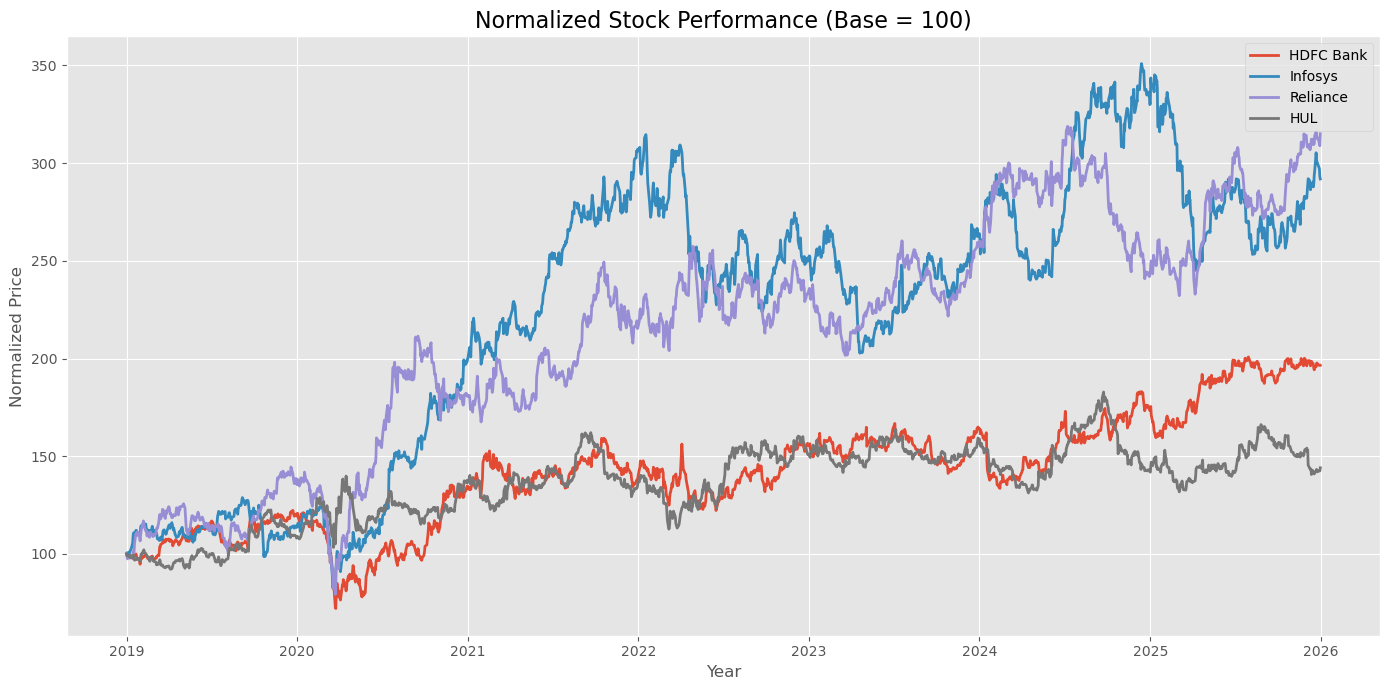

In [24]:
# ============================================================
# Normalized Price Performance
# ============================================================

normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(14,7))

for stock in normalized.columns:

    plt.plot(
        normalized.index,
        normalized[stock],
        linewidth=2,
        label=stock
    )

plt.title("Normalized Stock Performance (Base = 100)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Normalized Price")

plt.legend()

plt.tight_layout()

plt.show()

In [25]:
normalized.head()

,HDFC Bank,Infosys,Reliance,HUL
Date,,,,
2019-01-01,100.000000,100.000000,100.000000,100.000000
2019-01-02,99.087577,100.601467,98.697600,99.083886
2019-01-03,98.310138,100.616508,97.479932,99.294886
2019-01-04,98.573143,99.398544,98.006244,98.922879
2019-01-07,98.722124,100.999928,98.550411,99.103317


In [26]:
# ============================================================
# Calculate Daily Returns
# ============================================================

daily_returns = prices.pct_change()

daily_returns.head()

,HDFC Bank,Infosys,Reliance,HUL
Date,,,,
2019-01-01,NaN,NaN,NaN,NaN
2019-01-02,-0.009124,0.006015,-0.013024,-0.009161
2019-01-03,-0.007846,0.000150,-0.012337,0.002130
2019-01-04,0.002675,-0.012105,0.005399,-0.003746
2019-01-07,0.001511,0.016111,0.005552,0.001824


Interview question.

Why use returns instead of prices?

Answer:

Returns remove the effect of different share prices and represent the actual gains or losses experienced by investors over time.

In [27]:
daily_returns = daily_returns.dropna()

In [28]:
daily_returns.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
HDFC Bank,1729.0,0.0005,0.0157,-0.1261,-0.0069,0.0005,0.0076,0.1160
Infosys,1729.0,0.0008,0.0173,-0.1619,-0.0082,0.0007,0.0096,0.1203
Reliance,1729.0,0.0008,0.0177,-0.1315,-0.0086,0.0005,0.0088,0.1472
HUL,1729.0,0.0003,0.0142,-0.0887,-0.0071,-0.0003,0.0070,0.1350


Markdown
Descriptive Statistics of Daily Returns

Summary statistics are calculated for the daily return series of each stock.

These statistics provide preliminary insight into the behaviour of returns by reporting:

average daily return,
standard deviation,
minimum and maximum daily returns,
and quartiles.

The standard deviation serves as an initial indicator of the volatility associated with each stock

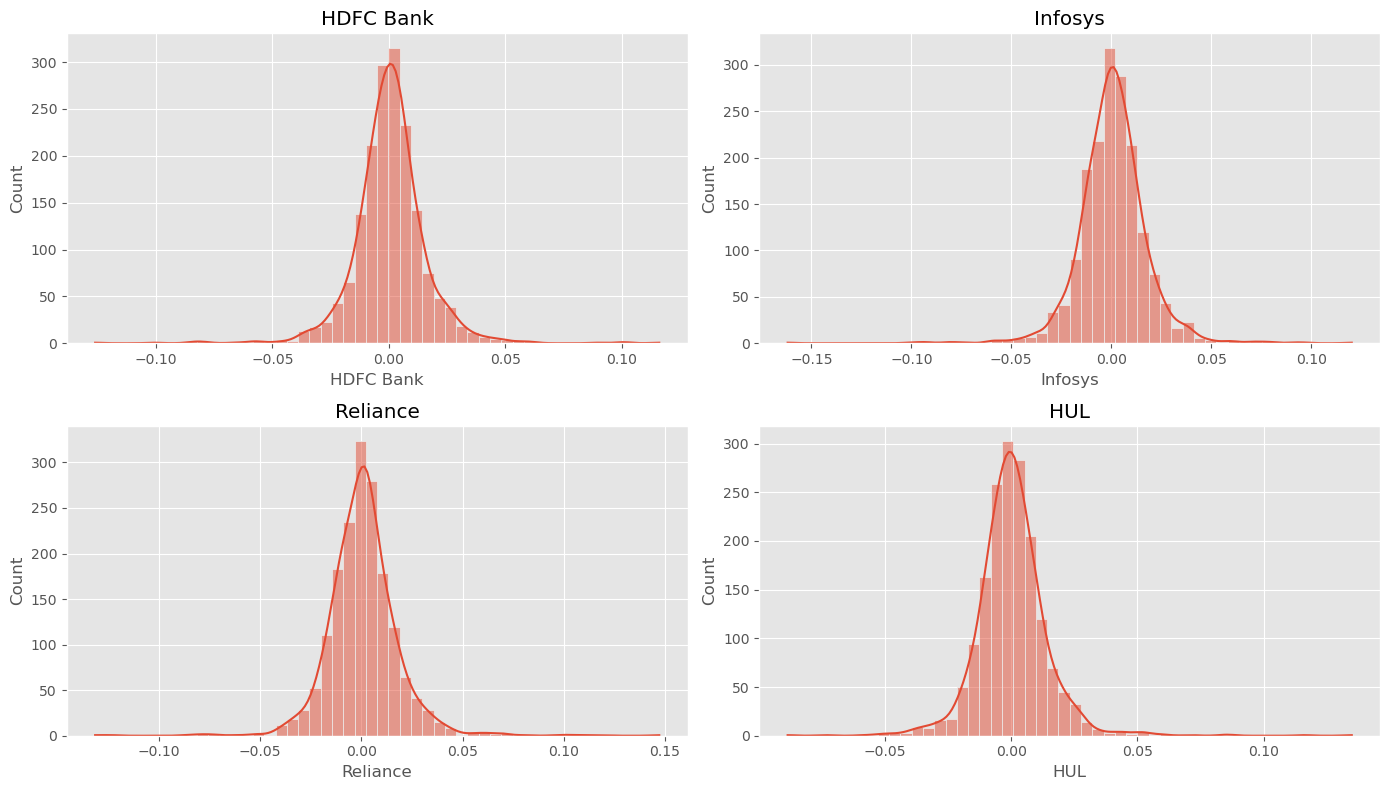

In [29]:
import seaborn as sns

plt.figure(figsize=(14,8))

for i, stock in enumerate(daily_returns.columns):

    plt.subplot(2,2,i+1)

    sns.histplot(
        daily_returns[stock],
        bins=50,
        kde=True
    )

    plt.title(stock)

plt.tight_layout()

plt.show()

enumerate numbers stocks into 0,1,2,4. Plt.subplot() requires rows, columns, position. Positon is shown by i+1--the position that particular stock should occupy. i+1 because subplot indexing starts from 1, while enumerate starts from 0

In [30]:
skewness={}
kurtosis={}
for stock in daily_returns.columns:
    skewness[stock]=daily_returns[stock].skew().round(4)
    kurtosis[stock]=daily_returns[stock].kurtosis().round(4)

In [41]:
symmetricity=pd.DataFrame(kurtosis.values(), index=kurtosis.keys())

In [44]:
df=pd.concat([symmetricity,pd.DataFrame(skewness.values(),index=skewness.keys())],axis=1)
df.columns=['Kurtosis','Skewness']
df

,Kurtosis,Skewness
HDFC Bank,9.6635,-0.0837
Infosys,9.7924,-0.3452
Reliance,10.2563,0.4507
HUL,11.1637,1.0243


In [45]:
from scipy.stats import jarque_bera

# Test normality of daily returns
for stock in daily_returns.columns:
    statistic, p_value = jarque_bera(daily_returns[stock].dropna())

    print(f"{stock}")
    print(f"JB Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Reject H0: Returns are not normally distributed")
    else:
        print("Fail to reject H0: Insufficient evidence against normality")

    print()

HDFC Bank
JB Statistic: 6685.9115
P-value: 0.0000
Reject H0: Returns are not normally distributed

Infosys
JB Statistic: 6897.7263
P-value: 0.0000
Reject H0: Returns are not normally distributed

Reliance
JB Statistic: 7587.8133
P-value: 0.0000
Reject H0: Returns are not normally distributed

HUL
JB Statistic: 9222.9546
P-value: 0.0000
Reject H0: Returns are not normally distributed



In [31]:
#correl matrix
correlation = daily_returns.corr()

correlation

,HDFC Bank,Infosys,Reliance,HUL
HDFC Bank,1.000000,0.301702,0.417030,0.252882
Infosys,0.301702,1.000000,0.303970,0.270727
Reliance,0.417030,0.303970,1.000000,0.294459
HUL,0.252882,0.270727,0.294459,1.000000


Markdown
Correlation Analysis

The correlation matrix measures the strength and direction of linear relationships between the daily returns of the selected stocks.

Correlation values range between −1 and +1.

Lower correlations indicate greater diversification potential because the assets tend to move less closely together. Portfolio optimization benefits from combining assets that are not perfectly correlated.

Supervisor Notes

One of the best interview questions.

Why do investors like

low correlation?

Because diversification reduces portfolio risk.

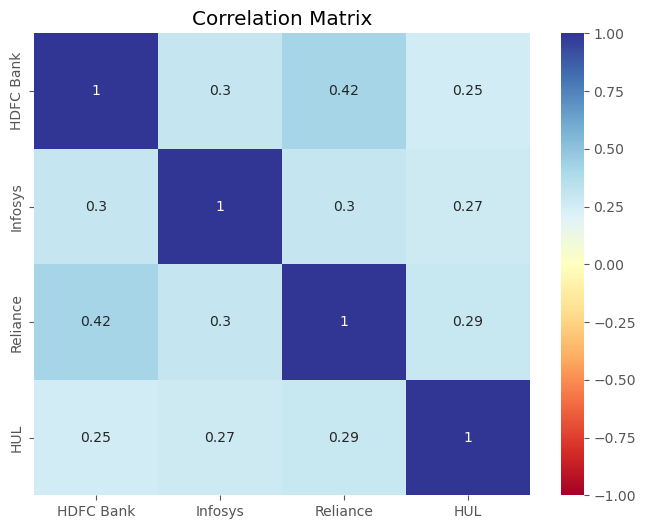

In [32]:

plt.figure(figsize=(8,6))

sns.heatmap(

    correlation,

    annot=True,

    cmap="RdYlBu",

    vmin=-1,

    vmax=1

)

plt.title("Correlation Matrix")

plt.show()

In [33]:
#rolling volatility
rolling_volatility = (
daily_returns.rolling(30).std()
)

Markdown
Estimating Rolling Volatility

Market volatility is not constant over time.

A 30-day rolling standard deviation of daily returns is calculated to observe how short-term volatility evolves throughout the study period.

Rolling volatility helps identify periods of increased market uncertainty, such as financial crises or sharp market corrections.

In [34]:
rolling_volatility

,HDFC Bank,Infosys,Reliance,HUL
Date,,,,
2019-01-02,NaN,NaN,NaN,NaN
2019-01-03,NaN,NaN,NaN,NaN
2019-01-04,NaN,NaN,NaN,NaN
2019-01-07,NaN,NaN,NaN,NaN
2019-01-08,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-12-24,0.007338,0.012860,0.007475,0.012097
2025-12-26,0.007382,0.012818,0.007470,0.012073
2025-12-29,0.007364,0.011847,0.007634,0.011966


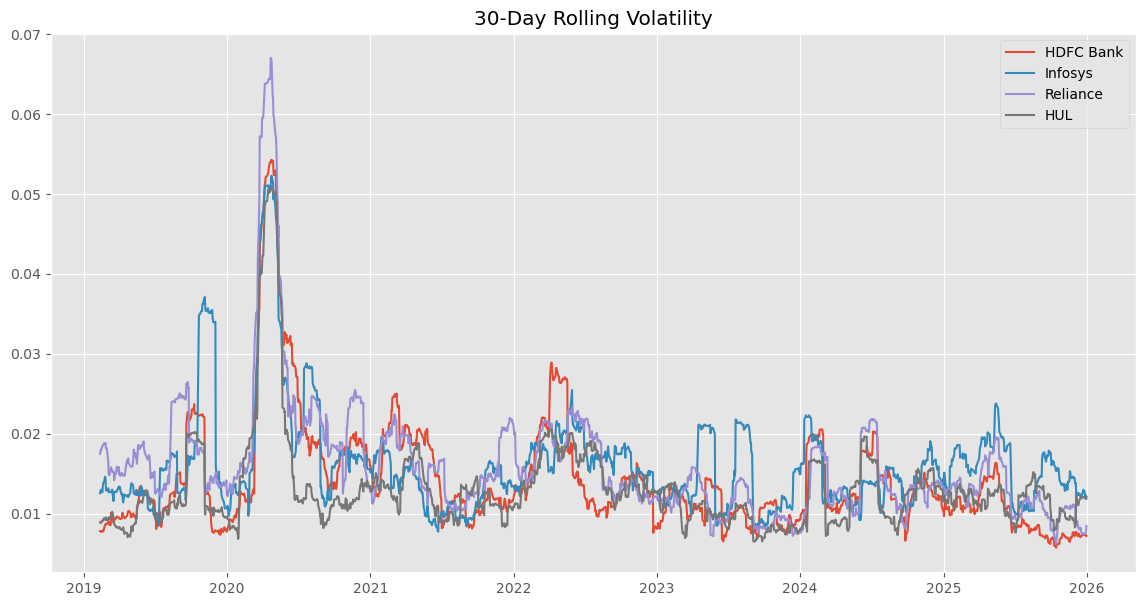

In [35]:
plt.figure(figsize=(14,7))

for stock in rolling_volatility.columns:

    plt.plot(

        rolling_volatility.index,

        rolling_volatility[stock],

        label=stock

    )

plt.title("30-Day Rolling Volatility")

plt.legend()

plt.show()

In [36]:
DOWNLOADS_DIR = Path.home() / "Downloads"
daily_returns.to_csv(DOWNLOADS_DIR/"daily_returns.csv")